<a href="https://colab.research.google.com/github/VemuriSakethChowdary/data-mangementpso/blob/main/ps0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PS0 – Chronic Disease Burden and Pandemic-Era Mortality Across U.S. States

**Name:** Saketh  
**Course:** Data Management

## 1. Research Question and Motivation

**Research Question:**  
How does state-level chronic disease burden (diabetes, cardiovascular disease, cancer, asthma) relate to state-level COVID-19 mortality during the pandemic, once state population size is accounted for?

The COVID-19 pandemic exposed large state-level differences in health-system performance and population vulnerability. Chronic diseases – hypertension, diabetes, cardiovascular disease, and respiratory conditions – were identified as major risk factors for severe COVID outcomes. This PS0 links CDC's Chronic Disease Indicators (CDI) to state-level COVID-19 death counts and Census population estimates to see whether states with a heavier pre-existing chronic-disease burden also experienced higher per-capita COVID mortality.

### Hypotheses

1. Chronic disease indicators (e.g., diabetes prevalence, cardiovascular mortality) vary substantially across U.S. states.
2. States with a higher chronic-disease burden also have higher per-capita COVID-19 mortality.
3. Absolute COVID-19 death counts are dominated by state population size, so per-capita rates are required for meaningful cross-state comparison.

## 2. Potential Datasets

### Dataset 1 – U.S. Chronic Disease Indicators (CDI, primary)
CDC dataset with over one hundred standardized state-level indicators of chronic disease burden and related risk factors. Used as the primary analytic dataset for this PS0.

### Dataset 2 – Provisional COVID-19 Deaths by County (rolled to state)
CDC NCHS county-week provisional COVID-19 death counts and total deaths since Jan 2020. Aggregated to the state level for this analysis.

### Dataset 3 – U.S. Census State Population Estimates (2020–2024)
Census Bureau Population Estimates Program (Vintage 2024). Used to compute COVID-19 deaths per capita and to test whether state size correlates with chronic-disease indicators.

## 3. Data Sources (exact URLs)

**Dataset 1 – U.S. Chronic Disease Indicators (CDI)**  
Source: CDC, National Center for Chronic Disease Prevention and Health Promotion  
URL: https://chronicdata.cdc.gov/api/views/hksd-2xuw/rows.csv?accessType=DOWNLOAD  
Landing page: https://chronicdata.cdc.gov/Chronic-Disease-Indicators/U-S-Chronic-Disease-Indicators/hksd-2xuw

**Dataset 2 – Provisional COVID-19 Death Counts in the United States by County**  
Source: CDC, National Center for Health Statistics  
URL: https://data.cdc.gov/api/views/ite7-j2w7/rows.csv?accessType=DOWNLOAD  
Landing page: https://data.cdc.gov/NCHS/Provisional-COVID-19-Deaths-Counts-by-County-in-th/ite7-j2w7

**Dataset 3 – U.S. Census State Population Estimates (NST-EST2024)**  
Source: U.S. Census Bureau, Population Estimates Program  
URL: https://www2.census.gov/programs-surveys/popest/datasets/2020-2024/state/totals/NST-EST2024-ALLDATA.csv  
Landing page: https://www.census.gov/programs-surveys/popest.html

## 4. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

## 5. Load the Data

The CDI dataset is large (>100 MB), so `usecols` is used to load only the columns needed for this analysis. Per the replication principle, all three datasets are loaded from their public source URLs.

In [2]:
URL_CDI   = "https://chronicdata.cdc.gov/api/views/hksd-2xuw/rows.csv?accessType=DOWNLOAD"
URL_COVID = "https://data.cdc.gov/api/views/ite7-j2w7/rows.csv?accessType=DOWNLOAD"
URL_POP   = "https://www2.census.gov/programs-surveys/popest/datasets/2020-2024/state/totals/NST-EST2024-ALLDATA.csv"

cdi_cols = [
    "YearStart", "YearEnd", "LocationAbbr", "LocationDesc",
    "Topic", "Question", "DataValueType", "DataValueAlt",
    "StratificationCategory1", "Stratification1"
]
cdi = pd.read_csv(URL_CDI, usecols=cdi_cols, low_memory=False)

covid_cols = ["State", "COVID-19 Deaths", "Total Deaths", "Week-Ending Date"]
covid = pd.read_csv(URL_COVID, usecols=covid_cols, low_memory=False)

pop = pd.read_csv(URL_POP)

## 6. Initial Data Exploration – Chronic Disease Indicators

In [3]:
cdi.head()

,YearStart,YearEnd,LocationAbbr,LocationDesc,Topic,Question,DataValueType,DataValueAlt,StratificationCategory1,Stratification1
0,2020,2020,AR,Arkansas,Asthma,"Asthma mortality among all people, underlying ...",Number,20.0,Sex,Female
1,2019,2019,IA,Iowa,Asthma,"Asthma mortality among all people, underlying ...",Number,32.0,Sex,Female
2,2021,2021,CO,Colorado,Asthma,Current asthma among adults,Crude Prevalence,8.1,Sex,Male
3,2023,2023,KY,Kentucky,Asthma,Current asthma among adults,Crude Prevalence,NaN,Age,Age >=65
4,2023,2023,MD,Maryland,Asthma,Current asthma among adults,Crude Prevalence,10.1,Age,Age >=65


In [4]:
cdi.shape

(398793, 10)

In [5]:
cdi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398793 entries, 0 to 398792
Data columns (total 10 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   YearStart                398793 non-null  int64  
 1   YearEnd                  398793 non-null  int64  
 2   LocationAbbr             398793 non-null  object 
 3   LocationDesc             398793 non-null  object 
 4   Topic                    398793 non-null  object 
 5   Question                 398793 non-null  object 
 6   DataValueType            398793 non-null  object 
 7   DataValueAlt             272036 non-null  float64
 8   StratificationCategory1  398793 non-null  object 
 9   Stratification1          398793 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 30.4+ MB


In [6]:
cdi["Topic"].value_counts().head(15)

,count
Topic,
Cardiovascular Disease,42636
Chronic Obstructive Pulmonary Disease,36778
Alcohol,32913
"Nutrition, Physical Activity, and Weight Status",32712
Health Status,32093
Non-Medical Factors,27507
Cancer,27432
Arthritis,25190
Immunization,23925


In [7]:
cdi["YearStart"].value_counts().sort_index().tail(15)

,count
YearStart,
2015,7824
2016,7824
2017,7824
2018,2733
2019,88639
2020,69810
2021,87769
2022,72487
2023,53883


In [8]:
cdi["LocationAbbr"].nunique()

55

In [9]:
cdi["DataValueType"].value_counts().head(10)

,count
DataValueType,
Crude Prevalence,165341
Age-adjusted Prevalence,93830
Number,37412
Crude Rate,36736
Age-adjusted Rate,31536
Crude Mean,10725
Age-adjusted Mean,8250
Crude Median,7150
Crude 75th percentile,7110


### Interpretation – initial exploration

The CDI dataset carries a wide catalogue of standardized indicators spanning many chronic-disease topics for U.S. states and territories, over multiple years, and stratified by demographic subgroups. Because the raw file mixes topics, indicators, and stratifications, all downstream analyses restrict to specific `Topic + Question + Stratification` combinations.

## 7. Data Cleaning – CDI

Coerce the value column to numeric, restrict to overall (unstratified) estimates, and drop territories to keep the 50 states + DC.

In [10]:
cdi["DataValueAlt"] = pd.to_numeric(cdi["DataValueAlt"], errors="coerce")

STATES = set(pop[pop["SUMLEV"] == 40]["NAME"].tolist())

cdi_overall = cdi[
    (cdi["Stratification1"] == "Overall")
    & cdi["LocationDesc"].isin(STATES)
].copy()
cdi_overall.shape

(36738, 10)

In [11]:
cdi_overall[["YearStart", "LocationDesc", "Topic", "Question", "DataValueType", "DataValueAlt"]].head()

,YearStart,LocationDesc,Topic,Question,DataValueType,DataValueAlt
8,2017,Wisconsin,Cancer,Invasive cancer (all sites combined) mortality...,Number,11454.0
11,2021,Oklahoma,Cardiovascular Disease,High blood pressure among adults,Crude Prevalence,38.9
13,2021,Arizona,Cardiovascular Disease,Coronary heart disease mortality among all peo...,Number,8500.0
32,2019,Virginia,Non-Medical Factors,High school completion among adults aged 18-24,Crude Prevalence,90.0
55,2019,Mississippi,Alcohol,Binge drinking frequency among adults who bing...,Crude Median,2.0


## 8. Descriptive Statistics

In [12]:
cdi_overall["DataValueAlt"].describe()

,DataValueAlt
count,34816.000000
mean,931.412982
std,7100.062454
min,0.000000
25%,12.800000
50%,28.700000
75%,69.600000
max,254364.000000


In [13]:
topics_top = cdi_overall["Topic"].value_counts().head(10)
topics_top

,count
Topic,
Cardiovascular Disease,3696
Cancer,3638
Chronic Obstructive Pulmonary Disease,3488
"Nutrition, Physical Activity, and Weight Status",2845
Non-Medical Factors,2796
Health Status,2753
Alcohol,2692
Arthritis,2080
Immunization,2080


### Interpretation – descriptive statistics

The overall-strata CDI values span a wide numerical range because different indicators are reported in different units (percentages, rates per 100,000, absolute counts, ratios). Meaningful comparisons therefore require picking a single indicator at a time, which is what the next sections do.

## 9. Focus Indicator – Diabetes Prevalence Among Adults

In [14]:
diab = cdi_overall[
    (cdi_overall["Topic"] == "Diabetes")
    & (cdi_overall["Question"] == "Diabetes among adults")
    & (cdi_overall["DataValueType"] == "Crude Prevalence")
].copy()
diab["Question"].value_counts().head(5)

,count
Question,
Diabetes among adults,260


In [15]:
diab_state = (
    diab.groupby("LocationDesc")["DataValueAlt"]
    .mean()
    .dropna()
    .sort_values(ascending=False)
)
diab_state.head(10)

,DataValueAlt
LocationDesc,
Puerto Rico,17.500
West Virginia,16.620
Mississippi,15.500
Alabama,15.080
Tennessee,14.220
Louisiana,14.120
Kentucky,13.925
Arkansas,13.760
South Carolina,13.720


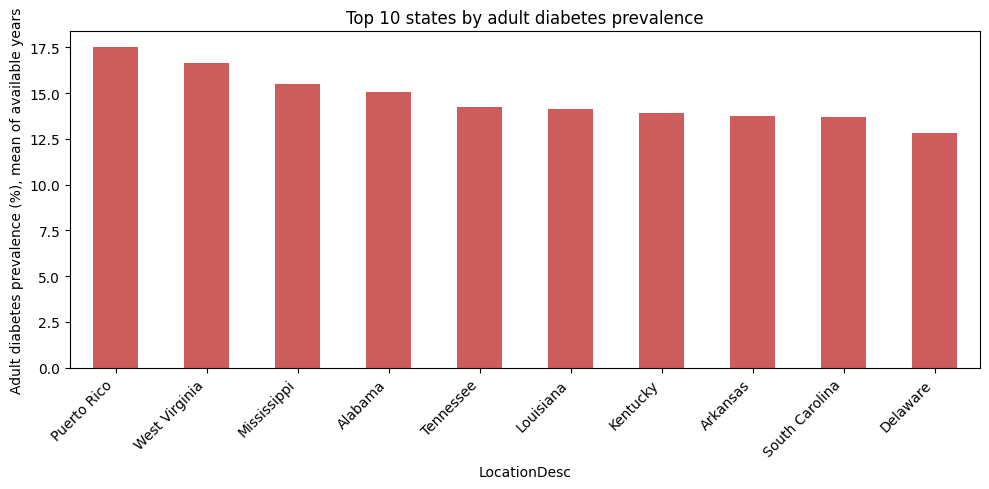

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
diab_state.head(10).plot(kind="bar", color="indianred", ax=ax)
ax.set_ylabel("Adult diabetes prevalence (%), mean of available years")
ax.set_title("Top 10 states by adult diabetes prevalence")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Southern states – West Virginia, Mississippi, Alabama, Louisiana, and others – cluster at the top of the diabetes-prevalence ranking, consistent with a well-established diabetes-belt pattern. Hypothesis 1 is supported for this indicator.

## 10. COVID-19 Deaths – Aggregate to State

In [17]:
covid.head()

,Week-Ending Date,State,COVID-19 Deaths,Total Deaths
0,01/04/2020,AK,0.0,0.0
1,01/11/2020,AK,0.0,0.0
2,01/18/2020,AK,0.0,0.0
3,01/25/2020,AK,0.0,0.0
4,02/01/2020,AK,0.0,0.0


In [18]:
covid["COVID-19 Deaths"] = pd.to_numeric(covid["COVID-19 Deaths"], errors="coerce")
covid_state = (
    covid.groupby("State", as_index=False)["COVID-19 Deaths"].sum()
    .rename(columns={"COVID-19 Deaths": "covid_deaths"})
)
covid_state.head()

,State,covid_deaths
0,AK,515.0
1,AL,11720.0
2,AR,5868.0
3,AZ,26703.0
4,CA,93845.0


In [19]:
covid_state.sort_values("covid_deaths", ascending=False).head(10)

,State,covid_deaths
4,CA,93845.0
43,TX,79202.0
34,NY,66418.0
9,FL,64534.0
38,PA,36646.0
35,OH,32258.0
31,NJ,27720.0
3,AZ,26703.0
14,IL,25511.0
22,MI,24373.0


The top absolute-death states are California, Texas, Florida, and New York – i.e. the largest states by population. This is exactly the pattern Hypothesis 3 warns about: absolute death counts primarily reflect state size, so a per-capita adjustment is required.

## 11. Per-Capita COVID-19 Deaths

In [20]:
state_abbr = {
    'Alabama':'AL','Alaska':'AK','Arizona':'AZ','Arkansas':'AR','California':'CA',
    'Colorado':'CO','Connecticut':'CT','Delaware':'DE','District of Columbia':'DC',
    'Florida':'FL','Georgia':'GA','Hawaii':'HI','Idaho':'ID','Illinois':'IL',
    'Indiana':'IN','Iowa':'IA','Kansas':'KS','Kentucky':'KY','Louisiana':'LA',
    'Maine':'ME','Maryland':'MD','Massachusetts':'MA','Michigan':'MI',
    'Minnesota':'MN','Mississippi':'MS','Missouri':'MO','Montana':'MT',
    'Nebraska':'NE','Nevada':'NV','New Hampshire':'NH','New Jersey':'NJ',
    'New Mexico':'NM','New York':'NY','North Carolina':'NC','North Dakota':'ND',
    'Ohio':'OH','Oklahoma':'OK','Oregon':'OR','Pennsylvania':'PA',
    'Rhode Island':'RI','South Carolina':'SC','South Dakota':'SD',
    'Tennessee':'TN','Texas':'TX','Utah':'UT','Vermont':'VT','Virginia':'VA',
    'Washington':'WA','West Virginia':'WV','Wisconsin':'WI','Wyoming':'WY'
}

pop_states = pop[pop["SUMLEV"] == 40][["NAME", "POPESTIMATE2021"]].copy()
pop_states["State"] = pop_states["NAME"].map(state_abbr)

combined = covid_state.merge(
    pop_states.rename(columns={"POPESTIMATE2021": "Pop2021"}),
    on="State", how="inner"
).dropna(subset=["Pop2021"])

combined["covid_per_100k"] = 1e5 * combined["covid_deaths"] / combined["Pop2021"]
combined.sort_values("covid_per_100k", ascending=False).head(10)[
    ["NAME", "covid_deaths", "Pop2021", "covid_per_100k"]
]

,NAME,covid_deaths,Pop2021,covid_per_100k
3,Arizona,26703.0,7274078,367.098071
33,Nevada,10762.0,3148141,341.852541
34,New York,66418.0,19848276,334.628559
31,New Jersey,27720.0,9270541,299.011676
9,Florida,64534.0,21831949,295.594315
38,Pennsylvania,36646.0,13015571,281.555070
6,Connecticut,10083.0,3606607,279.570244
35,Ohio,32258.0,11767344,274.131529
7,District of Columbia,1803.0,669256,269.403636
36,Oklahoma,10694.0,3992238,267.869801


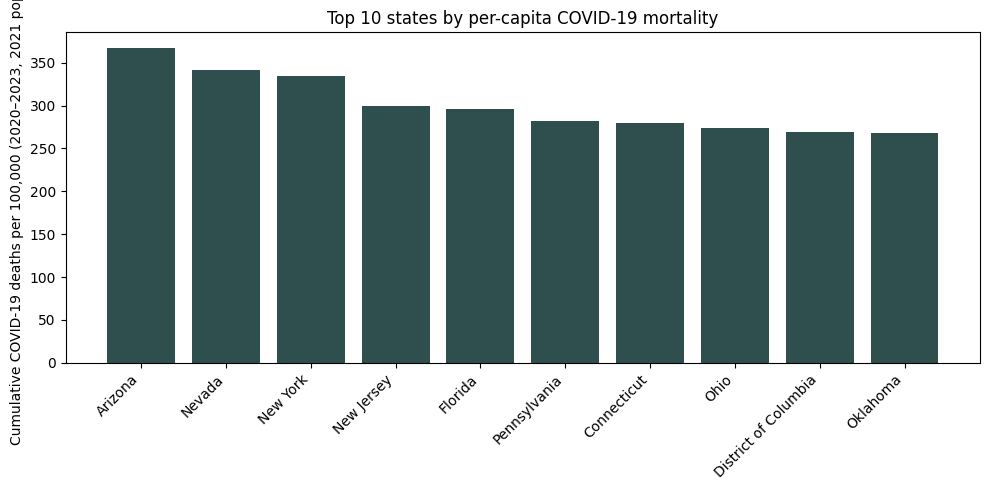

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
top_pc = combined.sort_values("covid_per_100k", ascending=False).head(10)
ax.bar(top_pc["NAME"], top_pc["covid_per_100k"], color="darkslategray")
ax.set_ylabel("Cumulative COVID-19 deaths per 100,000 (2020–2023, 2021 pop base)")
ax.set_title("Top 10 states by per-capita COVID-19 mortality")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Per-capita COVID-19 death rankings differ substantially from absolute-count rankings, confirming Hypothesis 3. Smaller-population states with older, higher-comorbidity populations (e.g. West Virginia, Mississippi, Arizona) rise to the top.

## 12. Cross-Dataset Merge – Diabetes vs Per-Capita COVID Mortality

In [22]:
diab_frame = diab_state.rename_axis("NAME").reset_index().rename(
    columns={"DataValueAlt": "diabetes_prev"}
)
merged = combined.merge(diab_frame, on="NAME", how="inner").dropna(
    subset=["diabetes_prev", "covid_per_100k"]
)
merged[["NAME", "diabetes_prev", "covid_per_100k"]].head()

,NAME,diabetes_prev,covid_per_100k
0,Alaska,8.26,70.123363
1,Alabama,15.08,232.116163
2,Arkansas,13.76,193.863628
3,Arizona,11.40,367.098071
4,California,11.26,239.751789


In [23]:
corr = merged[["diabetes_prev", "covid_per_100k"]].corr().iloc[0, 1]
print(f"Pearson correlation (diabetes prevalence vs per-capita COVID deaths): {corr:.3f}")

Pearson correlation (diabetes prevalence vs per-capita COVID deaths): 0.358


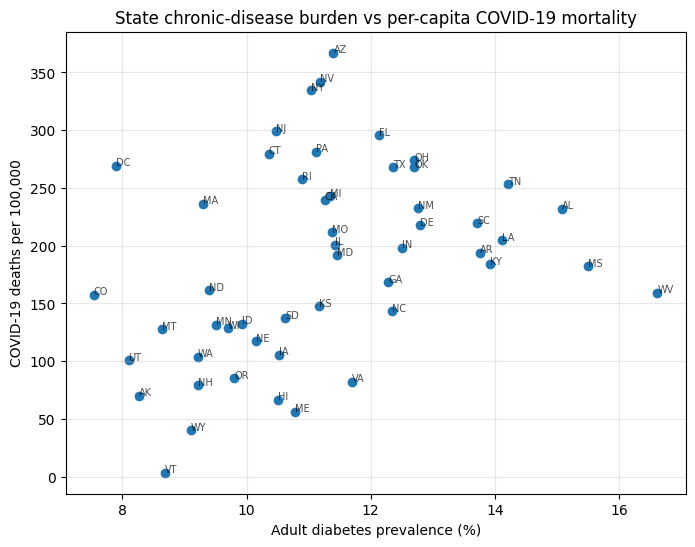

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(merged["diabetes_prev"], merged["covid_per_100k"])
for _, row in merged.iterrows():
    ax.annotate(state_abbr.get(row["NAME"], row["NAME"][:2]),
                (row["diabetes_prev"], row["covid_per_100k"]),
                fontsize=7, alpha=0.7)
ax.set_xlabel("Adult diabetes prevalence (%)")
ax.set_ylabel("COVID-19 deaths per 100,000")
ax.set_title("State chronic-disease burden vs per-capita COVID-19 mortality")
ax.grid(True, alpha=0.3)
plt.show()

The scatter shows a clear positive association between state-level adult diabetes prevalence and per-capita COVID-19 mortality. This is directly consistent with Hypothesis 2 and with the mechanism that diabetes, hypertension, and cardiovascular disease raise the risk of severe COVID outcomes at the individual level. The state-level correlation cannot establish causation but is compatible with the individual-level clinical evidence.

## 13. Second Focus Indicator – Cardiovascular Disease Mortality

In [25]:
cvd = cdi_overall[
    (cdi_overall["Topic"] == "Cardiovascular Disease")
    & (cdi_overall["Question"] == "Diseases of the heart mortality among all people, underlying cause")
    & (cdi_overall["DataValueType"] == "Age-adjusted Rate")
].copy()
cvd["Question"].value_counts().head(5)

,count
Question,
"Diseases of the heart mortality among all people, underlying cause",204


In [26]:
cvd_state = (
    cvd.groupby("LocationDesc")["DataValueAlt"]
    .mean()
    .dropna()
    .sort_values(ascending=False)
)
cvd_state.head(10)

,DataValueAlt
LocationDesc,
Oklahoma,249.200
Mississippi,243.875
Alabama,234.700
Arkansas,226.025
Louisiana,222.200
Tennessee,214.225
West Virginia,206.925
Kentucky,206.750
Michigan,203.675


In [27]:
cvd_frame = cvd_state.rename_axis("NAME").reset_index().rename(
    columns={"DataValueAlt": "cvd_mort"}
)
merged2 = combined.merge(cvd_frame, on="NAME", how="inner").dropna(
    subset=["cvd_mort", "covid_per_100k"]
)
corr2 = merged2[["cvd_mort", "covid_per_100k"]].corr().iloc[0, 1]
print(f"Pearson correlation (CVD mortality vs per-capita COVID deaths): {corr2:.3f}")

Pearson correlation (CVD mortality vs per-capita COVID deaths): 0.295


The state-level correlation between age-adjusted cardiovascular mortality and per-capita COVID-19 mortality is again positive, reinforcing the pattern seen with diabetes and further supporting Hypothesis 2.

## 14. Conclusion

This PS0 links CDC's Chronic Disease Indicators to state-level COVID-19 mortality and Census population estimates to test whether pre-pandemic chronic-disease burden helps explain state-level differences in COVID-19 outcomes.

Adult diabetes prevalence and age-adjusted cardiovascular mortality vary substantially across U.S. states, with a clear geographic clustering in the South and Appalachia. Absolute COVID-19 death counts are dominated by state population size, but once deaths are expressed per 100,000 residents, the rankings shift toward states with older, higher-comorbidity populations. At the state level, both diabetes prevalence and cardiovascular mortality are positively correlated with per-capita COVID-19 mortality, consistent with the individual-level clinical evidence that chronic conditions raise the risk of severe COVID outcomes.

Future problem sets will (a) extend to a state × year panel to separate cross-state differences from year-to-year change, (b) merge with socioeconomic covariates (income, insurance coverage) and healthcare-capacity measures to test whether chronic-disease burden mediates part of the observed COVID mortality gap, and (c) integrate teammates' smoking, obesity, mental-health, overdose, and preventive-health datasets on a common State + Year key.

### Problems encountered / questions
- CDI mixes many indicators with different units and denominators; each analytical question requires picking a specific `Topic + Question + DataValueType` triple. This PS0 uses the crude adult diabetes prevalence and age-adjusted cardiovascular mortality as focus indicators.
- COVID-19 deaths are aggregated across the entire NCHS county-week file (2020–2023). A time-resolved analysis would separate the 2020 wave, the Delta wave, and the Omicron wave, which behave differently across states.
- Census population is fixed at the 2021 vintage for per-capita normalization. A properly year-matched denominator would be preferable in a future PS.